# 01: C-MAPSSの探索的データ分析（EDA）

このノートブックでは、データを読み込み、品質・寿命分布・センサーの特徴を対話的に確認します。

## VS Codeでの操作

1. 右上の「カーネルの選択」で `.venv\Scripts\python.exe` を選びます。
2. セルを選び、`Shift+Enter`で1セルずつ実行します。
3. 値を変更したら、そのセル以降をもう一度実行します。

まずは上から順に実行してください。

## 1. プロジェクトと実験条件の設定

In [5]:
from pathlib import Path
import sys

# VS Codeの設定により通常はリポジトリ直下が作業フォルダになります。
# 念のため、notebooksフォルダが作業場所になっていても親を探せるようにします。
PROJECT_DIR = Path.cwd().resolve()
while PROJECT_DIR != PROJECT_DIR.parent and not (PROJECT_DIR / "CMAPSSData").exists():
    PROJECT_DIR = PROJECT_DIR.parent

if not (PROJECT_DIR / "CMAPSSData").exists():
    raise FileNotFoundError("CMAPSSDataが見つかりません。VS CodeでC-MAPSSフォルダを開いてください。")

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATASET = "FD001"  # FD002、FD003、FD004も指定できます。
RUL_CAP = 125

print(f"project: {PROJECT_DIR}")
print(f"dataset: {DATASET}")

project: C:\Users\taishi\learning-log\projects\C-MAPSS
dataset: FD001


## 2. ライブラリと共通関数の読み込み

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from cmapss.data import SENSOR_COLUMNS, add_rul, load_split
from cmapss.features import add_rolling_features, select_active_sensors

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", context="notebook")

## 3. データの読み込み

`train`には故障まで観測したデータ、`test`には故障前で観測が終了したデータが入ります。trainのRULは最終サイクルから逆算します。

In [16]:
train, test, test_rul = load_split(PROJECT_DIR / "CMAPSSData", DATASET)
train = add_rul(train, cap=RUL_CAP)

print(f"train: {train.shape[0]:,}行 × {train.shape[1]}列")
print(f"test : {test.shape[0]:,}行 × {test.shape[1]}列")
train.head()

train: 20,631行 × 28列
test : 13,096行 × 26列


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL_raw,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187,125


## 4. FD001〜FD004の大きさを比較

In [10]:
overview_rows = []
for name in ["FD001", "FD002", "FD003", "FD004"]:
    train_part, test_part, truth_part = load_split(PROJECT_DIR / "CMAPSSData", name)
    overview_rows.append({
        "dataset": name,
        "train_rows": len(train_part),
        "train_units": train_part["unit_id"].nunique(),
        "test_rows": len(test_part),
        "test_units": test_part["unit_id"].nunique(),
        "test_RUL_count": len(truth_part),
    })

overview = pd.DataFrame(overview_rows).set_index("dataset")
overview

,train_rows,train_units,test_rows,test_units,test_RUL_count
dataset,,,,,
FD001,20631,100,13096,100,100
FD002,53759,260,33991,259,259
FD003,24720,100,16596,100,100
FD004,61249,249,41214,248,248


## 5. 欠損値と重複行の確認

欠損値や完全に同じ重複行があると、モデル学習に影響する可能性があります。

In [11]:
quality = pd.DataFrame({
    "rows": [len(train), len(test)],
    "units": [train["unit_id"].nunique(), test["unit_id"].nunique()],
    "missing_values": [int(train.isna().sum().sum()), int(test.isna().sum().sum())],
    "duplicate_rows": [int(train.duplicated().sum()), int(test.duplicated().sum())],
}, index=["train", "test"])
quality

,rows,units,missing_values,duplicate_rows
train,20631,100,0,0
test,13096,100,0,0


## 6. エンジン寿命・観測期間の分布

In [12]:
train_lifetime = train.groupby("unit_id")["cycle"].max()
test_observed = test.groupby("unit_id")["cycle"].max()

pd.concat([
    train_lifetime.describe().rename("train_lifetime"),
    test_observed.describe().rename("test_observed_cycles"),
], axis=1).round(2)

,train_lifetime,test_observed_cycles
count,100.00,100.00
mean,206.31,130.96
std,46.34,53.59
min,128.00,31.00
25%,177.00,88.75
50%,199.00,133.50
75%,229.25,164.25
max,362.00,303.00


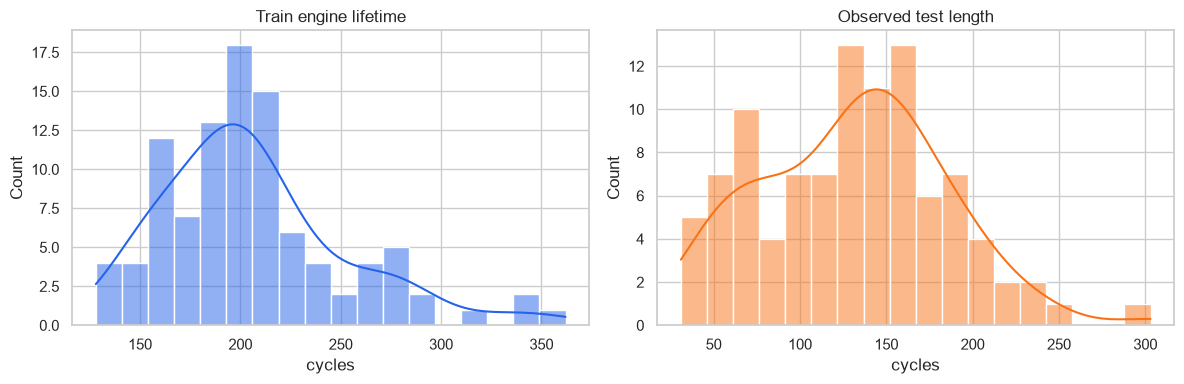

In [13]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_lifetime, bins=18, kde=True, ax=axes[0], color="#2563eb")
axes[0].set(title="Train engine lifetime", xlabel="cycles")
sns.histplot(test_observed, bins=18, kde=True, ax=axes[1], color="#f97316")
axes[1].set(title="Observed test length", xlabel="cycles")
plt.tight_layout()
plt.show()

## 7. センサーの分散とRULとの相関

標準偏差がほぼ0のセンサーは値がほとんど変化しないため、予測材料になりにくい列です。相関係数は-1〜1で、絶対値が1に近いほどRULと一緒に変化しています。

In [14]:
active_sensors = select_active_sensors(train)
constant_sensors = [sensor for sensor in SENSOR_COLUMNS if sensor not in active_sensors]

correlations = pd.Series(np.nan, index=SENSOR_COLUMNS, dtype=float)
correlations.loc[active_sensors] = train[active_sensors].corrwith(train["RUL"])
sensor_stats = pd.DataFrame({
    "mean": train[SENSOR_COLUMNS].mean(),
    "std": train[SENSOR_COLUMNS].std(),
    "n_unique": train[SENSOR_COLUMNS].nunique(),
    "corr_with_RUL": correlations,
})
sensor_stats["abs_corr_with_RUL"] = sensor_stats["corr_with_RUL"].abs()
sensor_stats = sensor_stats.sort_values("abs_corr_with_RUL", ascending=False)

print("一定値に近いセンサー:", constant_sensors)
sensor_stats.round(5)

一定値に近いセンサー: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


,mean,std,n_unique,corr_with_RUL,abs_corr_with_RUL
sensor_11,47.54117,0.26709,159,-0.77523,0.77523
sensor_4,1408.93378,9.00060,4051,-0.75716,0.75716
sensor_12,521.41347,0.73755,427,0.74887,0.74887
sensor_7,553.36771,0.88509,513,0.73302,0.73302
sensor_15,8.44215,0.03751,1918,-0.72086,0.72086
sensor_21,23.28971,0.10825,4745,0.70733,0.70733
sensor_20,38.81627,0.18075,120,0.70463,0.70463
sensor_17,393.21065,1.54876,13,-0.68083,0.68083
sensor_2,642.68093,0.50005,310,-0.67846,0.67846
sensor_3,1590.52312,6.13115,3012,-0.65503,0.65503


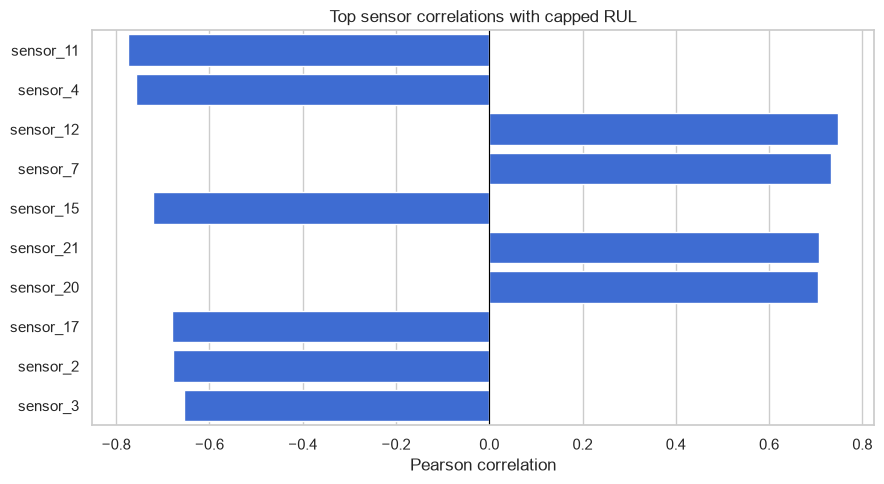

In [17]:
top_correlations = sensor_stats.loc[active_sensors].nlargest(10, "abs_corr_with_RUL")

plt.figure(figsize=(9, 5))
sns.barplot(
    data=top_correlations.reset_index(),
    x="corr_with_RUL",
    y="index",
    color="#2563eb",
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top sensor correlations with capped RUL")
plt.xlabel("Pearson correlation")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 8. 好きなエンジン・センサーを対話的に確認

次の`UNIT_ID`と`SENSOR`を書き換えて再実行すると、任意の劣化軌跡を確認できます。

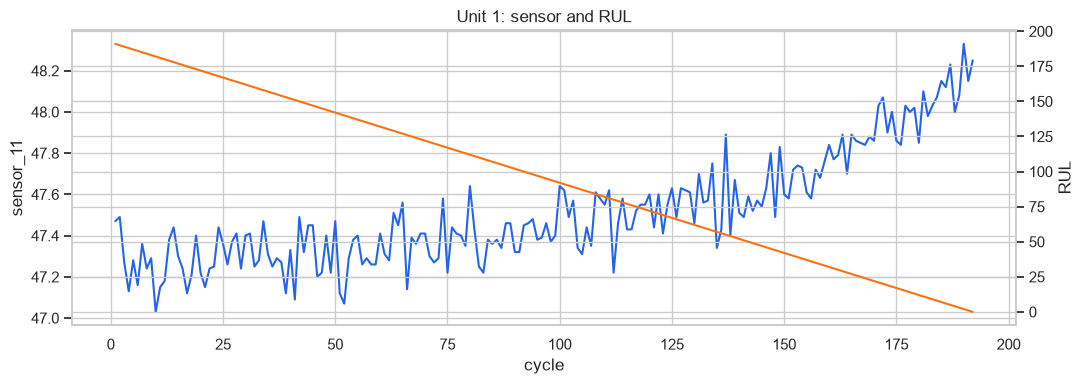

In [27]:
UNIT_ID = 1
SENSOR = "sensor_11"

engine = train.loc[train["unit_id"] == UNIT_ID]
figure, axis_left = plt.subplots(figsize=(11, 4))
axis_left.plot(engine["cycle"], engine[SENSOR], color="#2563eb", label=SENSOR)
axis_left.set(xlabel="cycle", ylabel=SENSOR, title=f"Unit {UNIT_ID}: sensor and RUL")

axis_right = axis_left.twinx()
axis_right.plot(engine["cycle"], engine["RUL_raw"], color="#f97316", label="RUL")
axis_right.set_ylabel("RUL")
figure.tight_layout()
plt.show()

## 9. 移動特徴量を実際に確認

In [28]:
featured = add_rolling_features(train, active_sensors, window=5)
columns_to_view = [
    "unit_id", "cycle", SENSOR,
    f"{SENSOR}_roll_mean_5",
    f"{SENSOR}_roll_std_5",
    f"{SENSOR}_delta",
    "RUL",
]
featured.loc[featured["unit_id"] == UNIT_ID, columns_to_view].head(10)

,unit_id,cycle,sensor_11,sensor_11_roll_mean_5,sensor_11_roll_std_5,sensor_11_delta,RUL
0,1,1,47.47,47.470,0.000000,0.00,125
1,1,2,47.49,47.480,0.014142,0.02,125
2,1,3,47.27,47.410,0.121655,-0.22,125
3,1,4,47.13,47.340,0.171659,-0.14,125
4,1,5,47.28,47.328,0.151063,0.15,125
5,1,6,47.16,47.266,0.141527,-0.12,125
6,1,7,47.36,47.240,0.094074,0.20,125
7,1,8,47.24,47.234,0.092628,-0.12,125
8,1,9,47.29,47.266,0.073348,0.05,125
9,1,10,47.03,47.216,0.127004,-0.26,125


## 次へ

データの特徴を確認できたら、`02_baseline.ipynb`を開いてモデル学習へ進みます。